# 01 - Exploratory Data Analysis

EDA of the EPSEM-UPC enrollment dataset.

Contents:
- Basic enrollment and grade distributions
- Temporal enrollment trends
- Missing data analysis
- Student progression patterns
- Cohort drift analysis
- Course autocorrelation
- Class imbalance per course
- Elective vs compulsory course variance

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from pathlib import Path
from educast.config import (
    UNIVERSITY_JSON, NUM_COURSES,
    EXCLUDE_FIRST_YEAR_IDS, EXCLUDE_OPTIONAL_IDS,
)
from educast.data.loader import (
    load_university_json,
    build_course_vocabulary,
    build_course_label_map,
)

In [2]:
FIGURES_DIR = Path("../../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Data

Data is loaded from `data/interim/EPSEM_data_private/EPSEM_semester.educast.json`.
The JSON contains 505 students, 51 courses, and their full enrollment histories.

In [3]:
# DATA NOT INCLUDED — contact the author or see README for access instructions.
university_data = load_university_json()
course_ids, course_to_idx, idx_to_course = build_course_vocabulary(university_data)
labels = build_course_label_map(university_data, idx_to_course)

students = university_data["students"]
print(f"University: {university_data['name']}")
print(f"Students: {len(students)}")
print(f"Courses: {len(course_ids)}")
print(f"Departments: {len(university_data.get('departments', []))}")
print(f"Programmes: {len(university_data.get('programmes', []))}")

University: EPSEM (Escola Politècnica Superior d'Enginyeria de Manresa)
Students: 505
Courses: 51
Departments: 1
Programmes: 1


The dataset covers the TIC programme at EPSEM-UPC (Manresa), 2010-2021.
49 of the 51 defined courses have actual enrollment records (2 are curriculum placeholders).
The `course_ids` vocabulary is sorted and used as the consistent column index for all 51-dim vectors.

## 2. Enrollment Distributions

How many courses does a typical student take per term? Which courses are most/least popular?

Course popularity is uneven: first-year compulsory courses (MBE, F, ISD, etc.)
appear for nearly all students, while electives and final-year subjects are sparse.

In [4]:
# Flatten all attempts into a DataFrame
records = []
for s in students:
    for att in s["history"]["attempts"]:
        records.append({
            "student_id": s["student_id"],
            "course_id": att["course"]["course_id"],
            "course_name": att["course"].get("name", att["course"]["course_id"]),
            "year": att.get("year"),
            "term": att.get("term"),
            "semester": att.get("semester"),
            "grade": att.get("grade"),
        })

df = pd.DataFrame(records)
print(f"Total enrollment records: {len(df)}")
print(f"Unique students: {df['student_id'].nunique()}")
print(f"Unique courses: {df['course_id'].nunique()}")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
df.head()

Total enrollment records: 11928
Unique students: 505
Unique courses: 49
Year range: 2010 - 2021


,student_id,course_id,course_name,year,term,semester,grade
0,75745a,330212,Matemàtiques Bàsiques Enginyeria,2010,1,1,7.4
1,75745a,330213,Física,2010,1,1,6.2
2,75745a,330214,Informàtica,2010,1,1,10.0
3,75745a,330215,Introducció als Sistemes Digitals,2010,1,1,9.0
4,75745a,330216,Fonaments Matemàtics per a TIC,2010,1,1,7.5


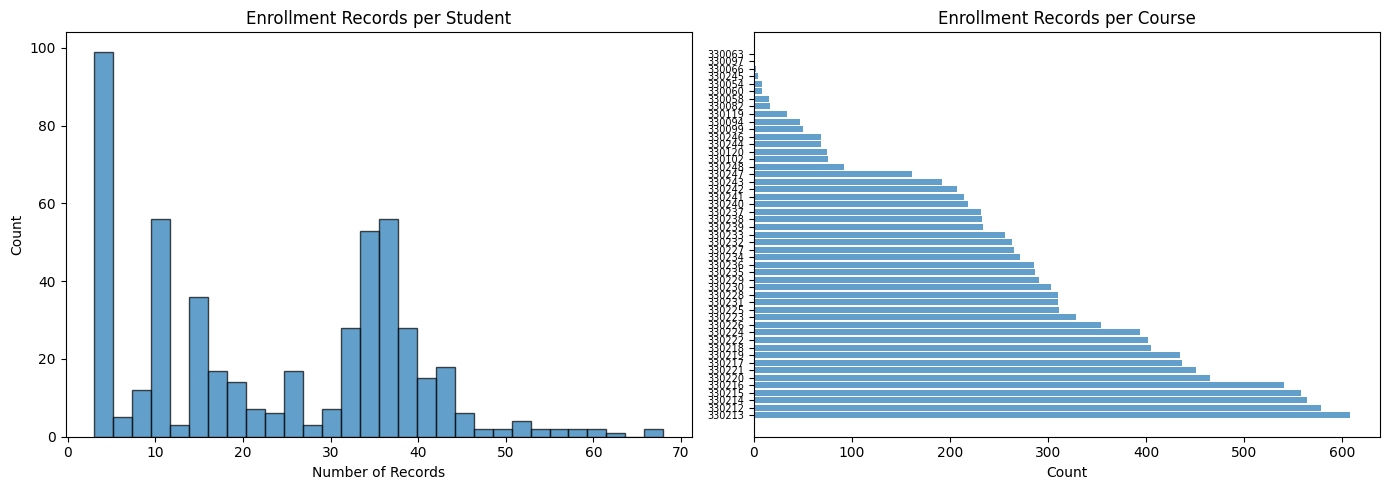

In [5]:
# Enrollments per student
enr_per_student = df.groupby("student_id").size()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(enr_per_student, bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title("Enrollment Records per Student")
axes[0].set_xlabel("Number of Records")
axes[0].set_ylabel("Count")

# Enrollments per course
enr_per_course = df.groupby("course_id").size().sort_values(ascending=False)
axes[1].barh(range(len(enr_per_course)), enr_per_course.values, alpha=0.7)
axes[1].set_yticks(range(len(enr_per_course)))
axes[1].set_yticklabels(enr_per_course.index, fontsize=7)
axes[1].set_title("Enrollment Records per Course")
axes[1].set_xlabel("Count")
plt.tight_layout()
plt.show()

- Enrollment records per student follow a right-uneven distribution, most students have 10-30 records.
- Course popularity is uneven: first-year compulsory courses appear ~500 times, advanced electives fewer than 50.
- This distributn in optional courses explains why per-course MAE is higher for electives in the LSTM models.

## 3. Grade Analysis

In the 153-dim TFM feature vector, grades are stored as `G_k = grade/10.0 ∈ [0,1]` (or `-1` if not enrolled).

Graded records: 11773 / 11928 (98.7%)
Pass rate (grade >= 5): 78.5%
Mean grade: 5.75


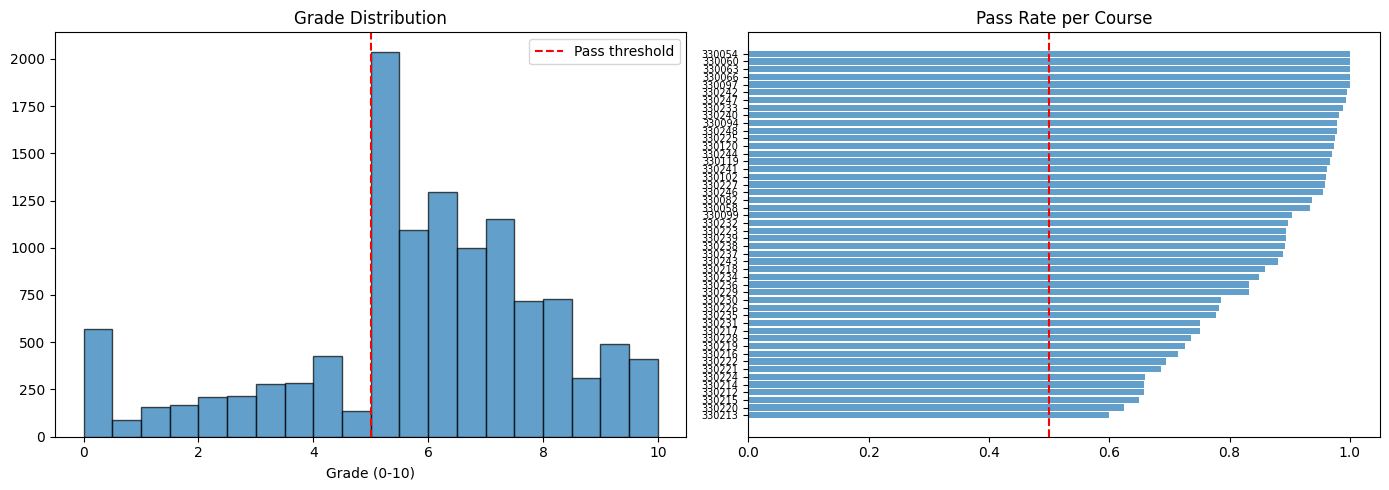

In [6]:
# Grade distribution
df_graded = df.dropna(subset=["grade"])
print(f"Graded records: {len(df_graded)} / {len(df)} ({100*len(df_graded)/len(df):.1f}%)")
print(f"Pass rate (grade >= 5): {(df_graded['grade'] >= 5).mean():.1%}")
print(f"Mean grade: {df_graded['grade'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_graded["grade"], bins=20, edgecolor="black", alpha=0.7)
axes[0].axvline(5.0, color="red", linestyle="--", label="Pass threshold")
axes[0].set_title("Grade Distribution")
axes[0].set_xlabel("Grade (0-10)")
axes[0].legend()

# Pass rate per course
pass_rates = df_graded.groupby("course_id")["grade"].apply(lambda x: (x >= 5).mean()).sort_values()
axes[1].barh(range(len(pass_rates)), pass_rates.values, alpha=0.7)
axes[1].set_yticks(range(len(pass_rates)))
axes[1].set_yticklabels(pass_rates.index, fontsize=7)
axes[1].set_title("Pass Rate per Course")
axes[1].axvline(0.5, color="red", linestyle="--")
plt.tight_layout()
plt.show()

## 4. Temporal Enrollment Trends

Total university enrollment over time and seasonal patterns (term 1 vs term 2).

The enrollment heatmap is directly the Macro LSTM input: each column is one input vector.
Temporal autocorrelation visible here explains why the naive baseline (last-semester copy) is hard to beat.

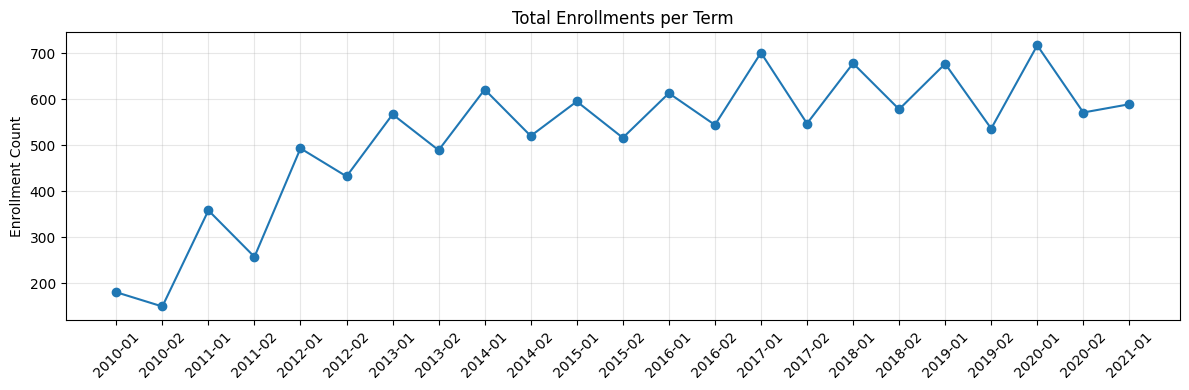

In [7]:
# Enrollments per term
df["term_key"] = df["year"].astype(str) + "-" + df["term"].astype(str).str.zfill(2)
term_counts = df.groupby("term_key").size().sort_index()

plt.figure(figsize=(12, 4))
plt.plot(range(len(term_counts)), term_counts.values, marker="o")
plt.xticks(range(len(term_counts)), term_counts.index, rotation=45)
plt.title("Total Enrollments per Term")
plt.ylabel("Enrollment Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

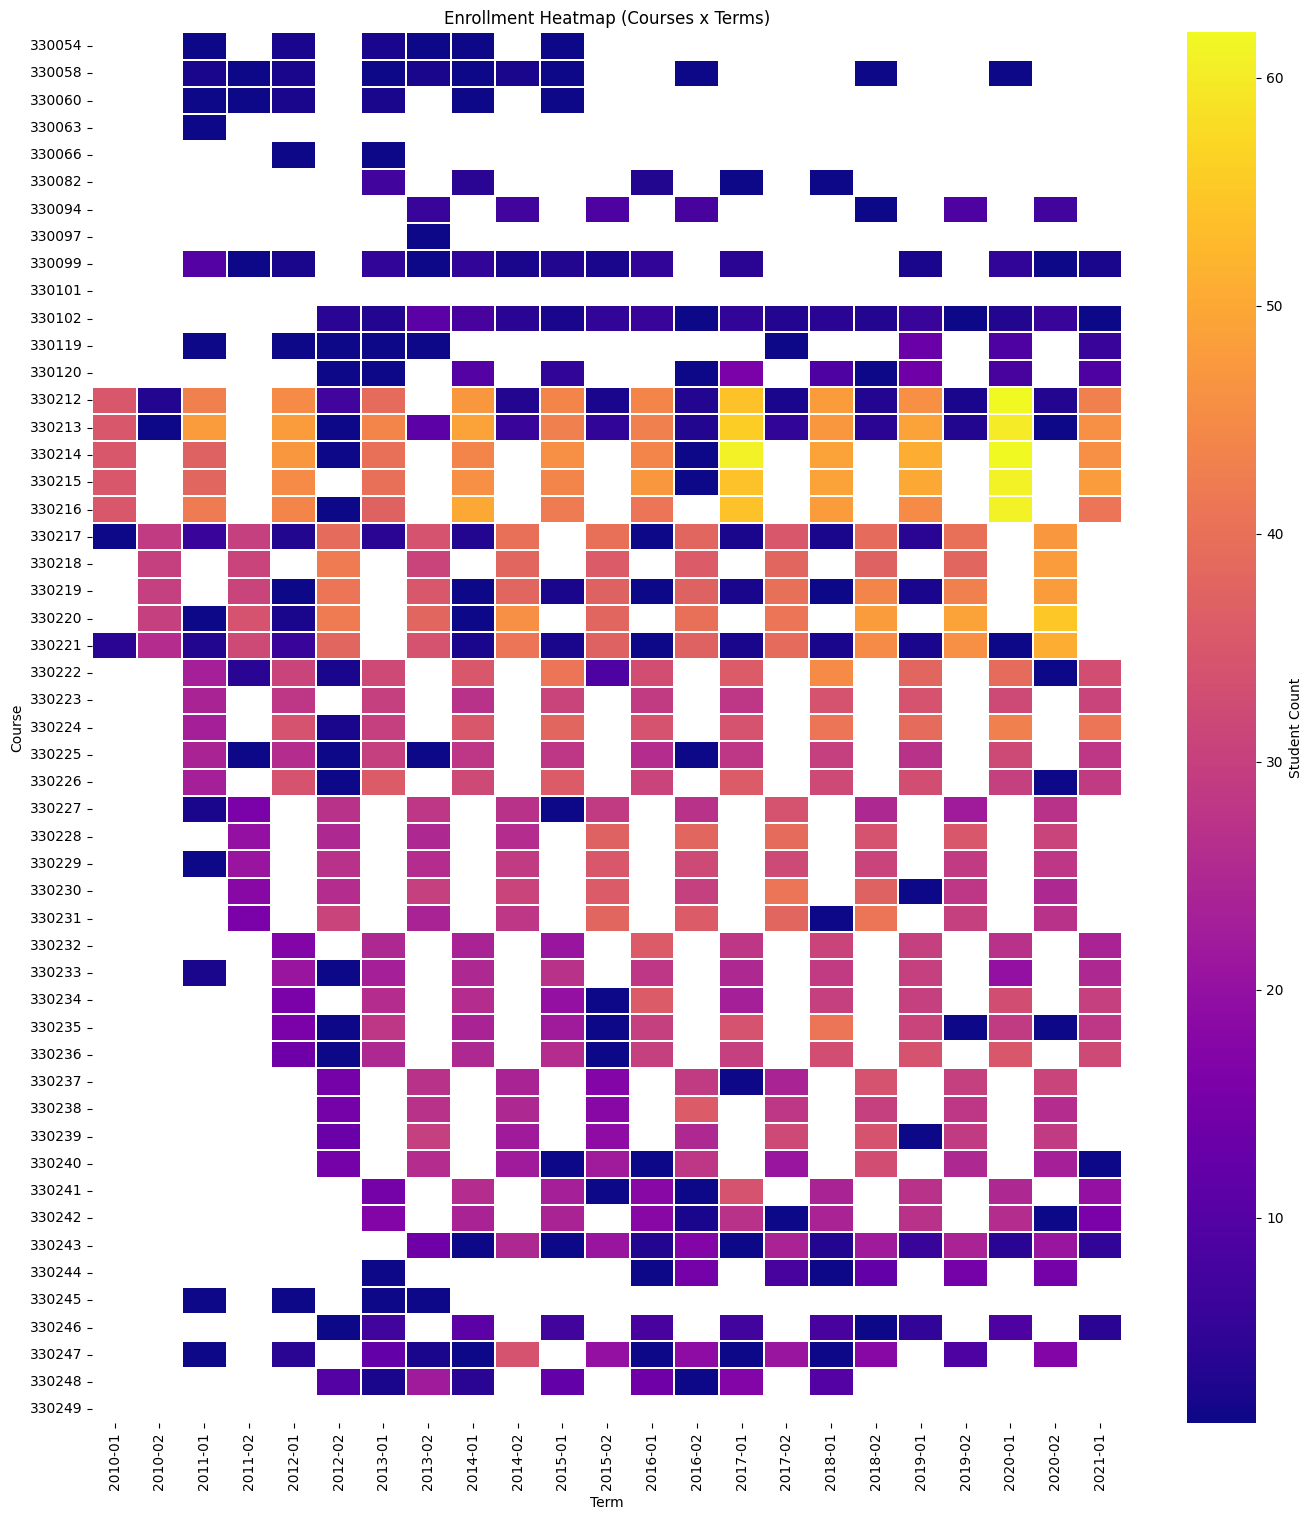

In [8]:
# University-wide enrollment heatmap
from educast.data.transforms import create_macro_dataset

df_macro = create_macro_dataset(university_data, course_ids)

plt.figure(figsize=(14, max(10, len(course_ids) * 0.3)))
sns.heatmap(
    df_macro.T, cmap="plasma", mask=df_macro.T == 0,
    linewidths=0.1, linecolor="white",
    cbar_kws={"label": "Student Count"},
)
plt.title("Enrollment Heatmap (Courses x Terms)")
plt.xlabel("Term")
plt.ylabel("Course")
plt.tight_layout()
plt.show()

## 5. Missing Data Analysis

Missing grades are enrollment records without a final grade (administrative withdrawals, incomplete records).

Only 155 missing out of 11,928 records (1.3%) pretty much negligible.
In the TFM feature vector, missing grades are encoded as `-1` (not enrolled)

In [9]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"Rows with any missing: {df.isnull().any(axis=1).sum()}")

Missing values per column:
grade    155
dtype: int64

Total missing: 155
Rows with any missing: 155


## 6. Student Progression Patterns

Distribution of how many distinct terms each student is enrolled, and the implications for LSTM training.

The Micro LSTM uses windows of 3 consecutive terms.
Students with fewer than 3 active terms contribute no LSTM training samples.

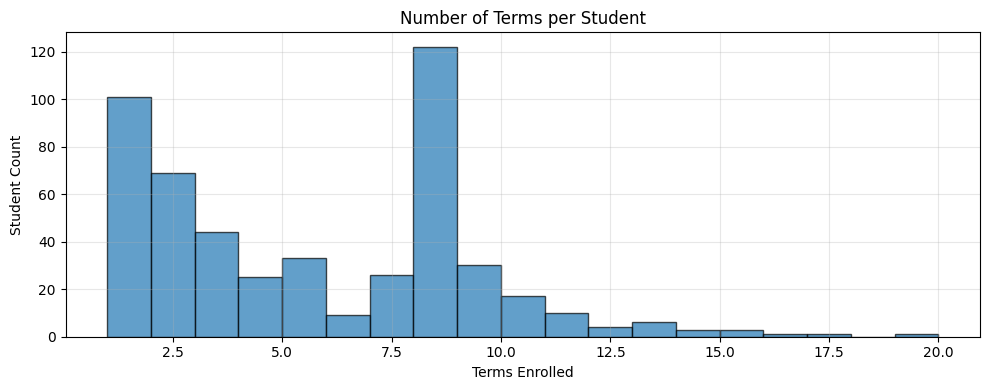

Mean terms per student: 5.3
Median: 5
Max: 19


In [10]:
# Number of unique terms per student
terms_per_student = df.groupby("student_id")["term_key"].nunique()

plt.figure(figsize=(10, 4))
plt.hist(terms_per_student, bins=range(1, terms_per_student.max() + 2), edgecolor="black", alpha=0.7)
plt.title("Number of Terms per Student")
plt.xlabel("Terms Enrolled")
plt.ylabel("Student Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean terms per student: {terms_per_student.mean():.1f}")
print(f"Median: {terms_per_student.median():.0f}")
print(f"Max: {terms_per_student.max()}")

- Most students are active for 6-10 terms (3-5 academic years), consistent with a 4-year degree.
- Significant tail with 1-2 terms: likely dropouts or transfer students, excluded from LSTM training.
- A small group with 12+ terms: students who extended their degree or had many retakes.

## 7. Cohort Size Drift Analysis

In [11]:
# Determine each student's entry year (year of their first enrollment record)
entry_year = df.groupby("student_id")["year"].min().rename("entry_year")
cohort_sizes = entry_year.value_counts().sort_index()

print("New students entering per year (cohort sizes):")
print(cohort_sizes.to_string())
print(f"\nMean cohort size: {cohort_sizes.mean():.1f}")
print(f"Std cohort size: {cohort_sizes.std():.1f}")
print(f"CV (std/mean): {cohort_sizes.std() / cohort_sizes.mean():.2f}")

New students entering per year (cohort sizes):
entry_year
2010    35
2011    37
2012    45
2013    36
2014    42
2015    41
2016    41
2017    51
2018    43
2019    40
2020    54
2021    40

Mean cohort size: 42.1
Std cohort size: 5.7
CV (std/mean): 0.13


In [12]:
# Active students per term (unique students with at least one enrollment)
active_per_term = df.groupby("term_key")["student_id"].nunique().sort_index()

print("\nActive students per term:")
print(active_per_term.to_string())


Active students per term:
term_key
2010-01     35
2010-02     30
2011-01     64
2011-02     56
2012-01     94
2012-02     87
2013-01    114
2013-02    107
2014-01    129
2014-02    127
2015-01    130
2015-02    125
2016-01    135
2016-02    126
2017-01    153
2017-02    138
2018-01    152
2018-02    140
2019-01    151
2019-02    139
2020-01    159
2020-02    137
2021-01    135


/var/folders/zy/vwhqt1dn6bx96gfjzf8pt7qm0000gn/T/ipykernel_11370/1298672899.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


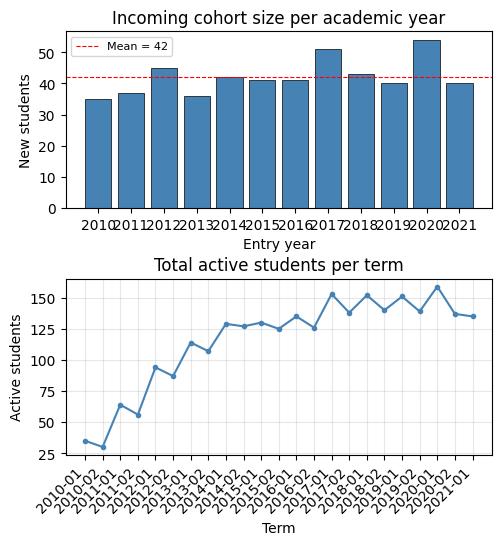

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(5.5, 5.5), gridspec_kw={"hspace": 0.4})

# Top: cohort sizes
ax = axes[0]
years = cohort_sizes.index.values
ax.bar(years, cohort_sizes.values, color="steelblue", edgecolor="black", linewidth=0.5)
ax.axhline(cohort_sizes.mean(), color="red", linestyle="--", linewidth=0.8, label=f"Mean = {cohort_sizes.mean():.0f}")
ax.set_xlabel("Entry year")
ax.set_ylabel("New students")
ax.set_title("Incoming cohort size per academic year")
ax.set_xticks(years)
ax.legend(fontsize=8)

# Bottom: active students per term
ax = axes[1]
x_pos = range(len(active_per_term))
ax.plot(x_pos, active_per_term.values, marker="o", markersize=3, color="steelblue")
ax.set_xticks(x_pos)
ax.set_xticklabels(active_per_term.index, rotation=45, ha="right")
ax.set_xlabel("Term")
ax.set_ylabel("Active students")
ax.set_title("Total active students per term")
ax.grid(True, alpha=0.3)

plt.savefig(f"{FIGURES_DIR}/eda_cohort_drift.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

The low coefficient of variation in cohort sizes (CV=0.13) confirms the naive baseline is a strong heuristic.
Year-over-year changes in incoming students are small relative to the total active population,
so aggregate course enrollment remains stable.

## 8. Student Tenure Distribution

In [16]:
# Count distinct terms per student
terms_per_student = df.groupby("student_id")["term_key"].nunique()

print(f"Student tenure (number of distinct terms enrolled):")
print(f"  Mean: {terms_per_student.mean():.1f}")
print(f"  Median: {terms_per_student.median():.0f}")
print(f"  Min: {terms_per_student.min()}, Max: {terms_per_student.max()}")
print()

# Windowing thresholds
n_1_2 = (terms_per_student <= 2).sum()
n_3 = (terms_per_student == 3).sum()
n_4_plus = (terms_per_student >= 4).sum()
total = len(terms_per_student)

print(f"Students with 1-2 terms (excluded from LSTM, window=3): {n_1_2} ({100*n_1_2/total:.1f}%)")
print(f"Students with exactly 3 terms (1 LSTM sample possible): {n_3} ({100*n_3/total:.1f}%)")
print(f"Students with 4+ terms (usable for window=3): {n_4_plus} ({100*n_4_plus/total:.1f}%)")

Student tenure (number of distinct terms enrolled):
  Mean: 5.3
  Median: 5
  Min: 1, Max: 19

Students with 1-2 terms (excluded from LSTM, window=3): 170 (33.7%)
Students with exactly 3 terms (1 LSTM sample possible): 44 (8.7%)
Students with 4+ terms (usable for window=3): 291 (57.6%)


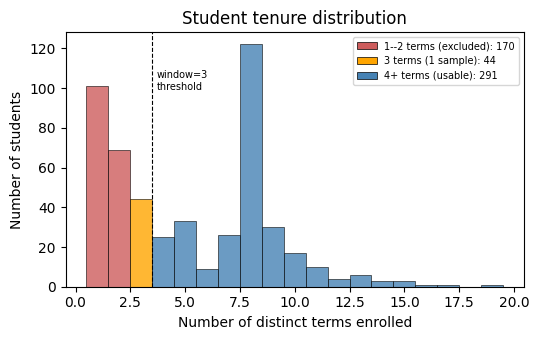

In [17]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))

bins = range(1, terms_per_student.max() + 2)
counts, bin_edges, patches = ax.hist(terms_per_student, bins=bins, edgecolor="black",
                                      linewidth=0.5, color="steelblue", alpha=0.8,
                                      align="left")

# Color the bars for excluded students (1-2 terms) in red
for i, patch in enumerate(patches):
    if bin_edges[i] <= 2:
        patch.set_facecolor("indianred")
    elif bin_edges[i] == 3:
        patch.set_facecolor("orange")

ax.axvline(3.5, color="black", linestyle="--", linewidth=0.8)
ax.text(3.7, ax.get_ylim()[1] * 0.85, "window=3\nthreshold", fontsize=7, va="top")

ax.set_xlabel("Number of distinct terms enrolled")
ax.set_ylabel("Number of students")
ax.set_title("Student tenure distribution")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="indianred", edgecolor="black", linewidth=0.5, label=f"1--2 terms (excluded): {n_1_2}"),
    Patch(facecolor="orange", edgecolor="black", linewidth=0.5, label=f"3 terms (1 sample): {n_3}"),
    Patch(facecolor="steelblue", edgecolor="black", linewidth=0.5, label=f"4+ terms (usable): {n_4_plus}"),
]
ax.legend(handles=legend_elements, fontsize=7, loc="upper right")

plt.savefig(f"{FIGURES_DIR}/eda_student_tenure.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()